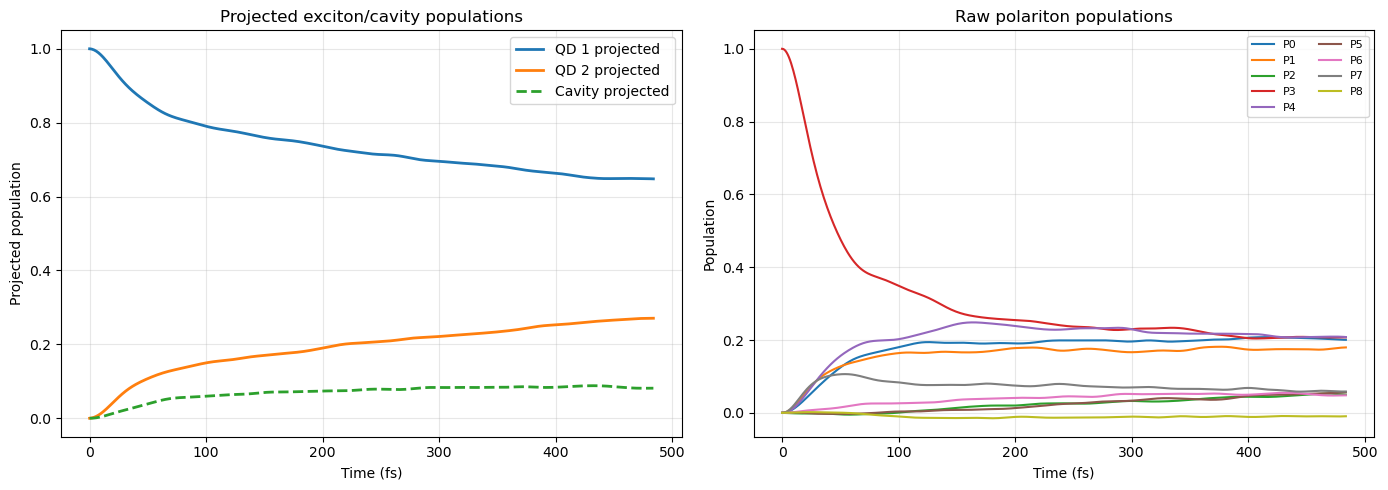

Polariton energies (eV, shifted by lowest):
  P0: 0.00000000
  P1: 0.00746247
  P2: 0.01127422
  P3: 0.01127422
  P4: 0.01158812
  P5: 0.01158812
  P6: 0.03426324
  P7: 0.05838557
  P8: 0.05838557

Max projected populations:
  QD 1: 1
  QD 2: 0.270685
  Cavity: 0.0880837

Mean total projected population: 1


In [4]:
#!/usr/bin/env python3
"""
Read polaritonic-basis populations from pop.out and project them onto
original exciton/cavity basis populations using polariton_transform_AU.npz.

State ordering in the original exciton/cavity basis:
- States 0-3: QD 1 exciton states
- States 4-7: QD 2 exciton states
- State 8: cavity photon state

Important: pop.out contains populations only. The projection below assumes the
polariton density matrix is diagonal, so it ignores polariton coherences.
"""

import numpy as np
import matplotlib.pyplot as plt

autos = 2.4188843265857e-17
n_qd = 2
nstate_per_qd = 4
n_cavity = 1
n_qd_states = n_qd * nstate_per_qd
n_exciton_states = n_qd_states + n_cavity

# pop.out is in the simulation basis. For this folder that basis is polaritonic.
data = np.loadtxt("pop.out")
time = data[:, 0] * autos * 1e15  # au to fs
polariton_pop = data[:, 1:]
n_states = polariton_pop.shape[1]

if n_states != n_exciton_states:
    raise ValueError(f"Expected {n_exciton_states} states, found {n_states}")

transform = np.load("polariton_transform_AU.npz")
U = transform["exciton_to_polariton_U"]
polariton_energies_AU = transform["polariton_energies_AU"]

if U.shape != (n_exciton_states, n_exciton_states):
    raise ValueError(f"Unexpected transformation matrix shape {U.shape}")

# U[i, a] = amplitude of exciton/cavity state i in polariton a.
# With populations only, project as p_i = sum_a |U_i,a|^2 p_a.
exciton_projected_pop = polariton_pop @ (np.abs(U) ** 2).T

qd_total_pop = np.zeros((len(time), n_qd))
for qd in range(n_qd):
    start_idx = qd * nstate_per_qd
    end_idx = (qd + 1) * nstate_per_qd
    qd_total_pop[:, qd] = exciton_projected_pop[:, start_idx:end_idx].sum(axis=1)

cavity_pop = exciton_projected_pop[:, n_qd_states]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
for qd in range(n_qd):
    ax.plot(time, qd_total_pop[:, qd], label=f"QD {qd + 1} projected", linewidth=2)
ax.plot(time, cavity_pop, label="Cavity projected", linewidth=2, linestyle="--")
ax.set_xlabel("Time (fs)")
ax.set_ylabel("Projected population")
ax.set_title("Projected exciton/cavity populations")
ax.legend()
ax.grid(alpha=0.3)

ax = axes[1]
for state in range(n_states):
    ax.plot(time, polariton_pop[:, state], label=f"P{state}")
ax.set_xlabel("Time (fs)")
ax.set_ylabel("Population")
ax.set_title("Raw polariton populations")
ax.legend(ncol=2, fontsize=8)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("Polariton energies (eV, shifted by lowest):")
energies_eV = (polariton_energies_AU - polariton_energies_AU.min()) * 27.2114079527
for state, energy in enumerate(energies_eV):
    print(f"  P{state}: {energy:.8f}")

print("\nMax projected populations:")
for qd in range(n_qd):
    print(f"  QD {qd + 1}: {qd_total_pop[:, qd].max():.6g}")
print(f"  Cavity: {cavity_pop.max():.6g}")
print(f"\nMean total projected population: {exciton_projected_pop.sum(axis=1).mean():.6g}")
